# Project 2: Student Exam Performance

## Project Overview
This notebook analyzes student academic, lifestyle, and socio-economic factors that may influence **Exam_Score**.  
The dataset includes variables related to study habits, attendance, sleep, motivation, tutoring, parental involvement, school type, and other environmental factors.

## Objective
The goal of this analysis is to:
1. inspect the dataset structure and data quality,
2. explore relationships between features and `Exam_Score`,
3. generate assumptions and verify them using statistical tests,
4. conclude with at least 7 clear insights supported by evidence.

## Scope
This notebook focuses on exploratory data analysis (EDA), visualization, and statistical testing to understand which factors are most associated with student final exam performance.

In [39]:
# Standard library
from pathlib import Path
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Reproducibility
np.random.seed(42)

# Plot style
sns.set_theme(style="whitegrid")

# Paths
DATA_PATH = Path("../data/StudentPerformanceFactors.csv")
OUTPUT_FIGURES = Path("../outputs/figures")
OUTPUT_TABLES = Path("../outputs/tables")

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

## Data Loading and Initial Validation

In this section, we load the dataset and perform quick validation checks to confirm that the file was read correctly.  
These checks help detect issues early, such as incorrect column names, unexpected data types, or missing values.

In [40]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 6607 rows and 20 columns


In [41]:
# Preview first rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [42]:
# Column names
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [43]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [44]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.00,19.98,5.99,1.00,16.00,20.00,24.00,44.00
Attendance,6607.00,79.98,11.55,60.00,70.00,80.00,90.00,100.00
Sleep_Hours,6607.00,7.03,1.47,4.00,6.00,7.00,8.00,10.00
Previous_Scores,6607.00,75.07,14.40,50.00,63.00,75.00,88.00,100.00
Tutoring_Sessions,6607.00,1.49,1.23,0.00,1.00,1.00,2.00,8.00
Physical_Activity,6607.00,2.97,1.03,0.00,2.00,3.00,4.00,6.00
Exam_Score,6607.00,67.24,3.89,55.00,65.00,67.00,69.00,101.00


In [45]:
# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64


The dataset contains missing values in a few categorical columns.  
Since the number of missing entries is relatively small compared to the dataset size, they are not expected to significantly impact the analysis.
For future work, these could be handled using:
- imputation (e.g., replacing with "Unknown")
- or excluding affected rows for specific analyses

## Initial Observations

Based on the initial inspection:

- The dataset contains **6607 rows** and **20 columns**, which is sufficient for exploratory analysis.
- The target variable is `Exam_Score`.
- The dataset includes a mix of numerical and categorical variables.
- Initial validation will help determine whether missing values or inconsistent data types require preprocessing before deeper analysis.

These observations provide the foundation for the next stage, where we separate variables by type and inspect their distributions.

In [46]:
target_col = "Exam_Score"

categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Target:", target_col)
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Target: Exam_Score
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


## Analysis Plan

To understand student exam performance, the next steps will focus on:

1. examining the target variable distribution,
2. exploring numerical features and their relationships with `Exam_Score`,
3. comparing categorical groups against `Exam_Score`,
4. testing selected hypotheses statistically,
5. summarizing the most important findings.

## Target Variable Analysis: Exam Score

We begin by analyzing the distribution of the target variable `Exam_Score`.

Understanding the distribution helps identify:
- whether scores follow a normal pattern
- presence of skewness
- potential outliers
- general performance level of students

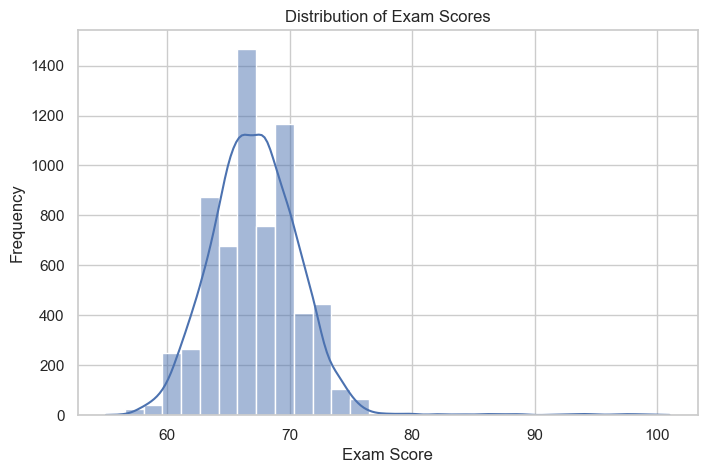

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"], bins=30, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Exam scores are mostly concentrated around the mid-to-high 60s, indicating relatively consistent student performance.  
The maximum value above 100 may indicate a possible outlier or data anomaly.

In [48]:
df["Exam_Score"].describe()

count   6607.00
mean      67.24
std        3.89
min       55.00
25%       65.00
50%       67.00
75%       69.00
max      101.00
Name: Exam_Score, dtype: float64

### Statistical Summary Insights

The summary statistics provide key numerical indicators:
- mean indicates the average student performance
- standard deviation shows score variability
- minimum and maximum show score range
- quartiles help understand distribution spread

These values help determine whether student performance varies significantly.

## Numerical Features Analysis

We now examine distributions of numerical variables such as:
- study hours
- sleep hours
- attendance
- tutoring sessions
- motivation level

Understanding their distributions helps identify patterns that may influence exam performance.

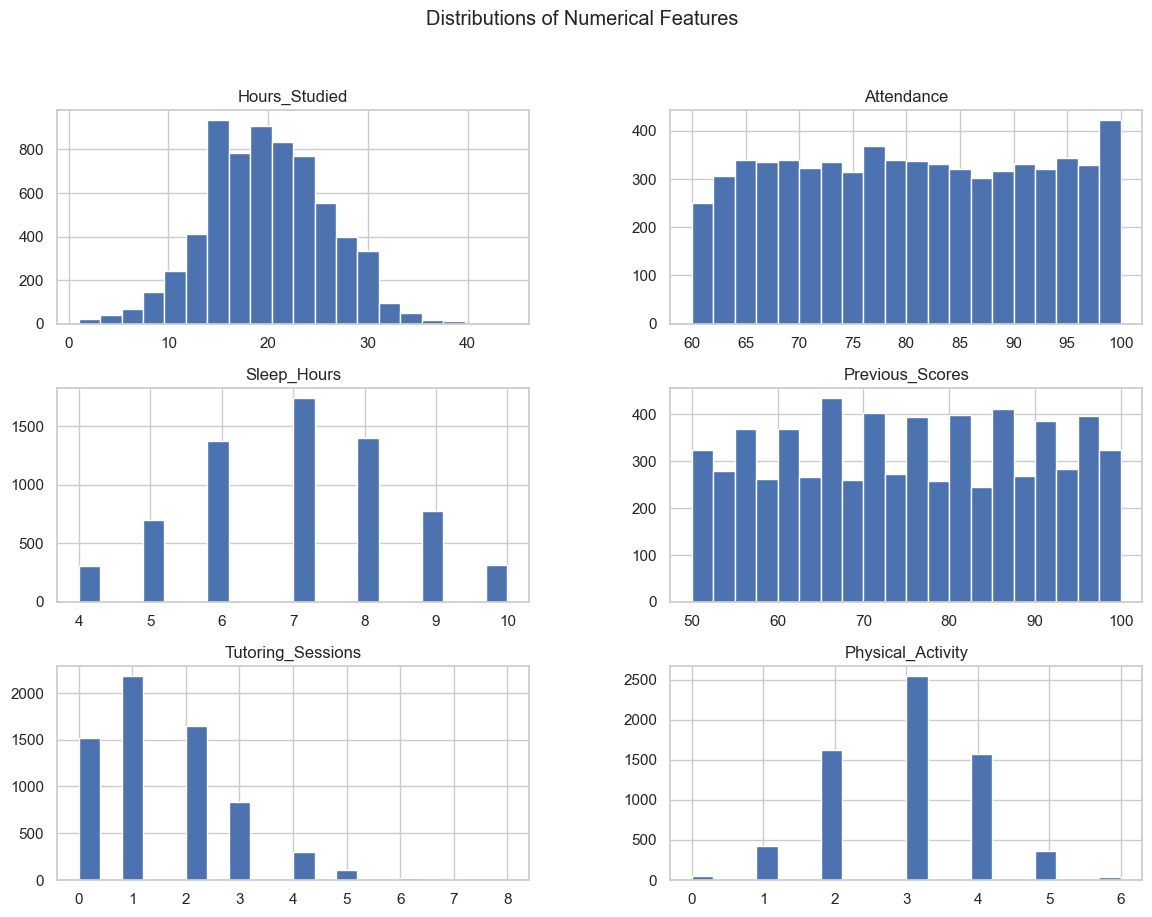

In [49]:
df[numerical_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Distributions of Numerical Features")
plt.show()

### Observations

From these distributions we can:
- identify skewed variables
- detect unusual values or outliers
- understand typical ranges of student habits

These insights guide feature selection and interpretation in later analysis.

## Relationship Between Numerical Features and Exam Score

We analyze how numerical variables relate to exam performance using scatterplots.

This helps determine:
- whether increasing study time improves performance
- whether sleep impacts scores
- whether attendance correlates with exam results

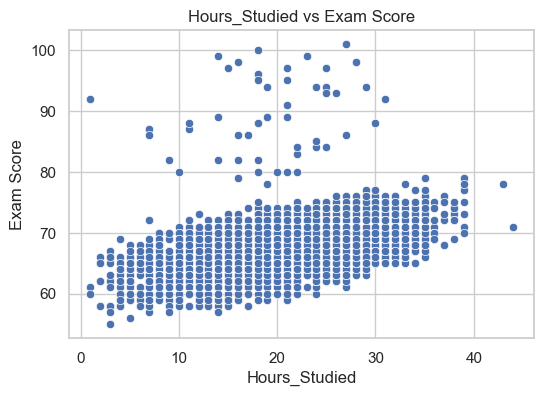

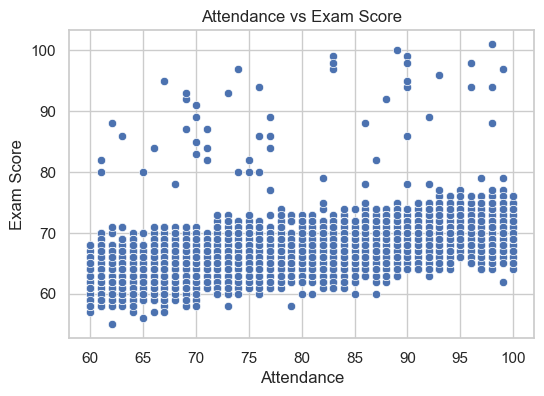

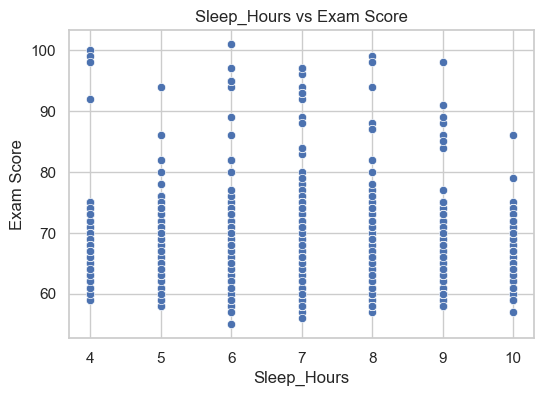

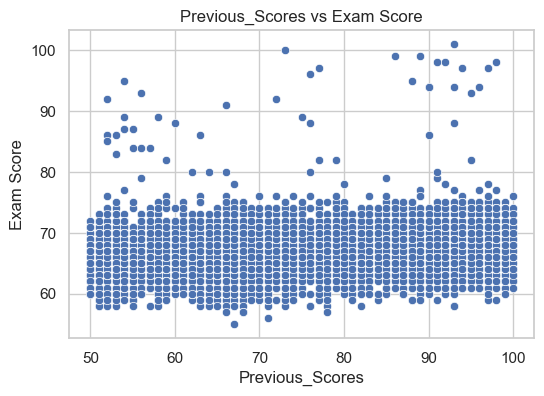

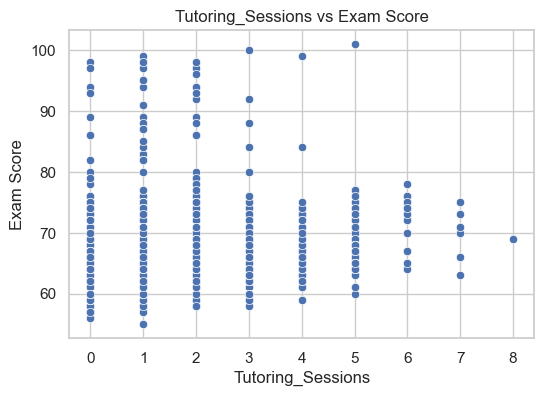

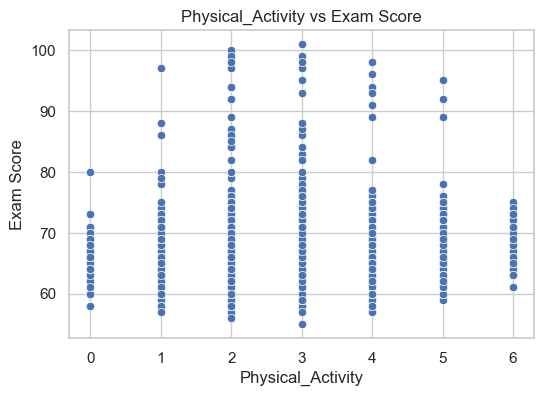

In [50]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y="Exam_Score")

    plt.title(f"{col} vs Exam Score")
    plt.xlabel(col)
    plt.ylabel("Exam Score")

    plt.show()

### Interpretation

Study hours and attendance show positive relationships with exam scores, suggesting that students who study more and attend classes regularly tend to perform better.  
Other variables such as sleep and physical activity show weaker relationships.

## Correlation Analysis

Correlation helps quantify the strength of relationships between numerical variables and exam scores.

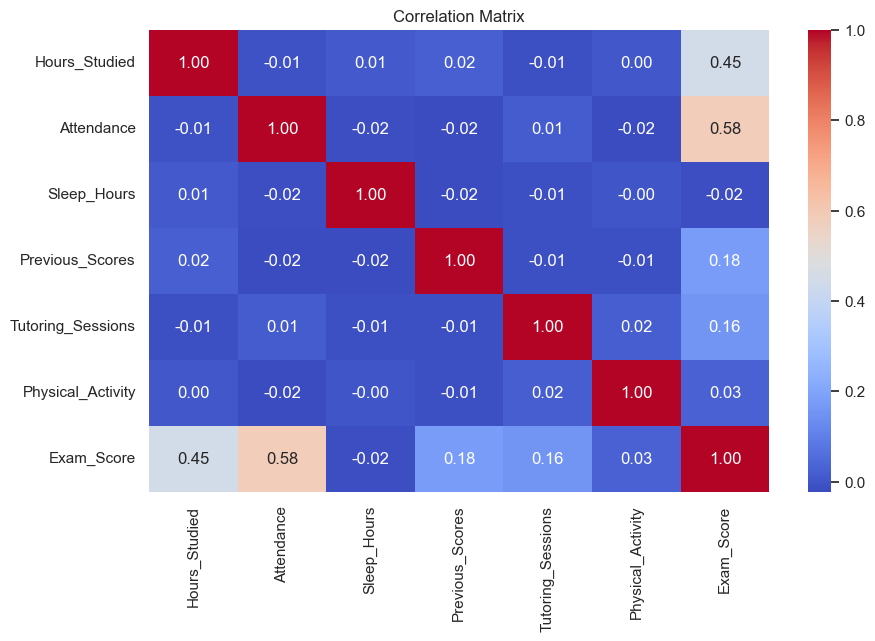

In [51]:
plt.figure(figsize=(10,6))

corr_matrix = df[numerical_cols + ["Exam_Score"]].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

### Interpretation

Attendance has the strongest relationship with exam score (~0.58), followed by study hours (~0.45).  
Previous scores and tutoring show weaker relationships, while sleep and physical activity show minimal correlation.

## Categorical Features Analysis

Categorical variables describe group differences such as:
- school type
- parental involvement
- access to tutoring
- motivation level categories

We compare average exam scores across categories.

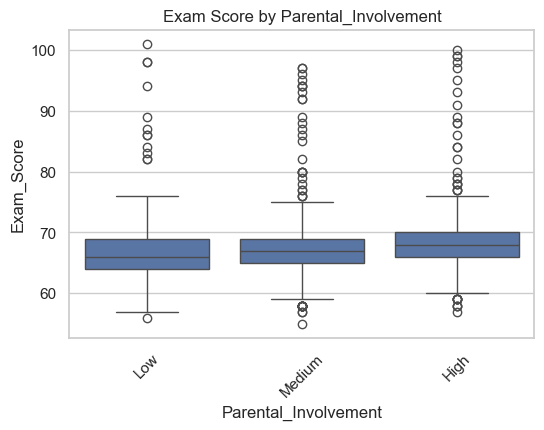

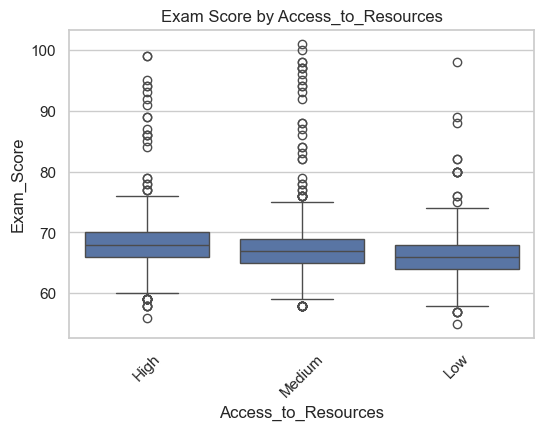

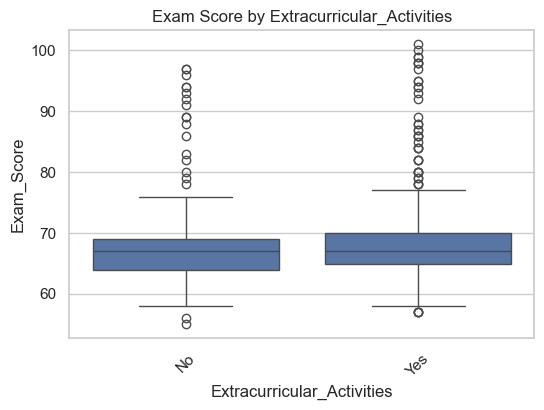

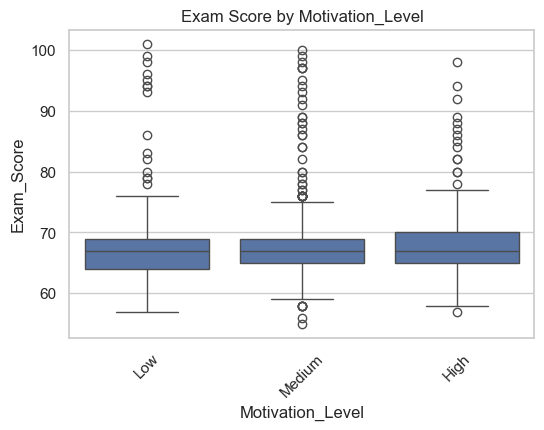

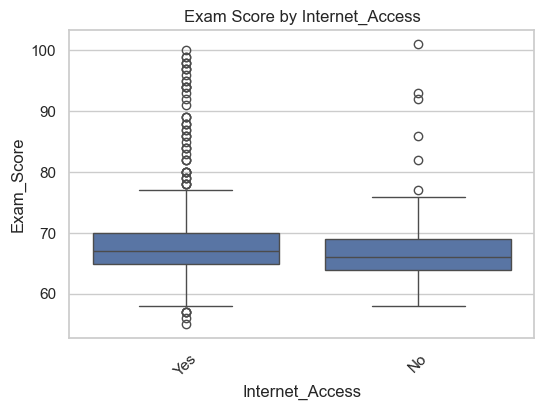

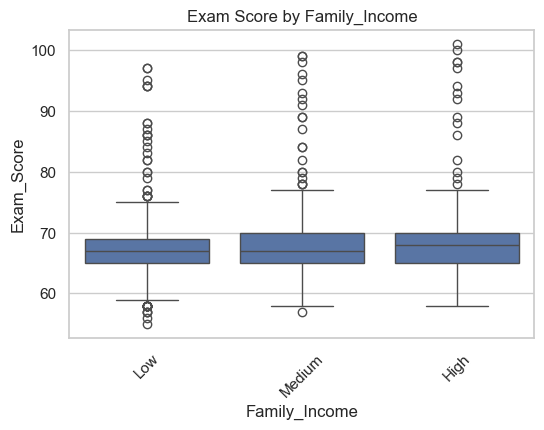

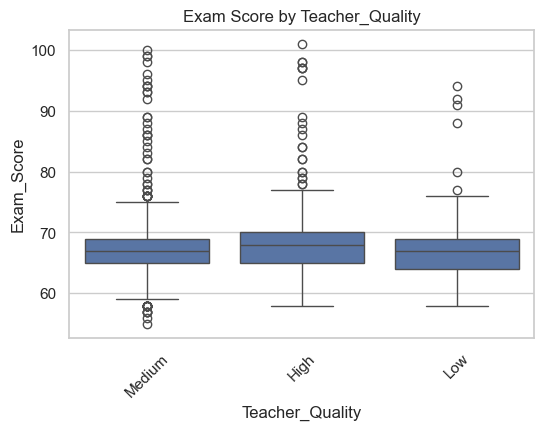

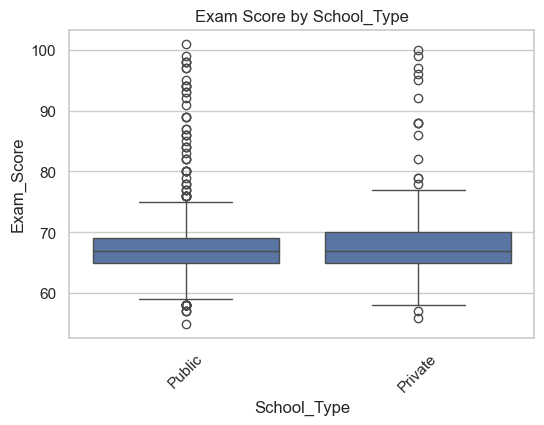

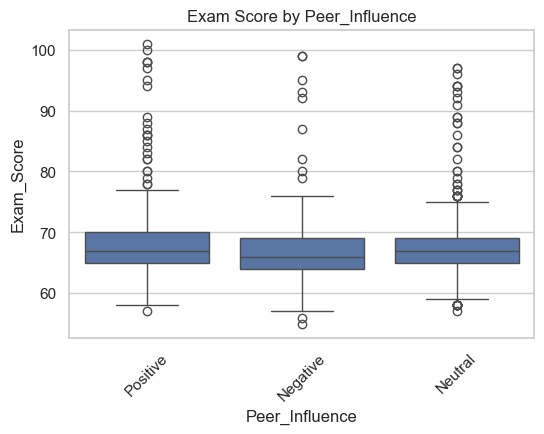

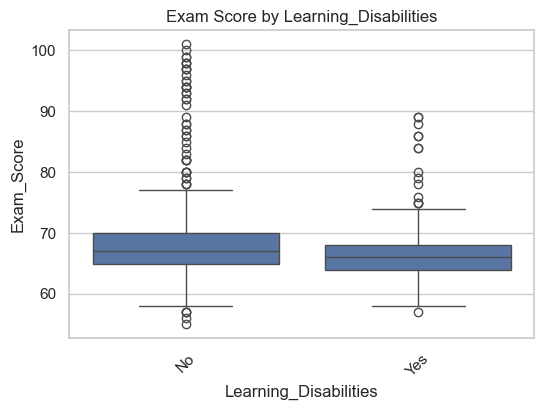

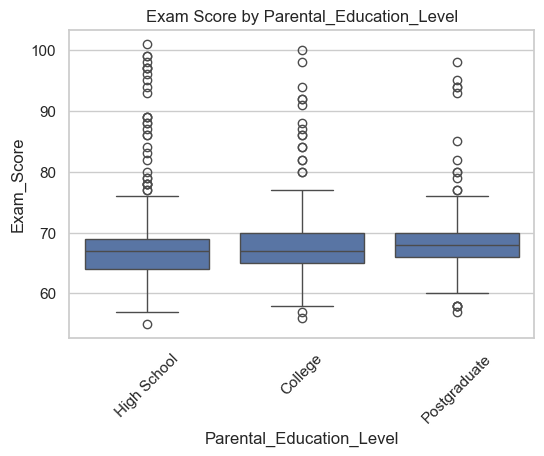

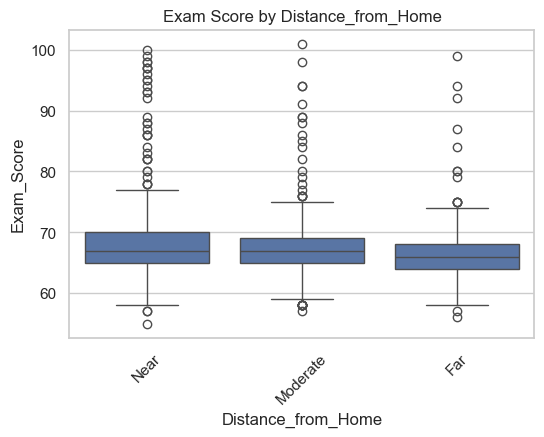

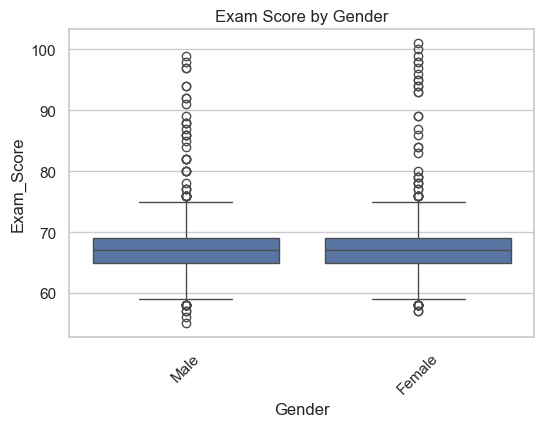

In [52]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(data=df, x=col, y="Exam_Score")

    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=45)

    plt.show()

### Observations

Boxplots help compare score distributions across categories.

We look for:
- groups with higher median scores
- groups with wider variability
- potential outliers

Differences between categories may indicate important social or environmental influences on performance.

## Hypothesis Testing Example

We test whether study hours significantly impact exam scores.

Hypothesis:
Students who study more tend to achieve higher exam scores.

In [53]:
correlation, p_value = stats.pearsonr(df["Hours_Studied"], df["Exam_Score"])

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.44545495407528213
P-value: 1.28635e-319


### Interpretation

Study hours have a statistically significant positive relationship with exam scores (p < 0.05), indicating that increased study time is associated with better performance.

In [54]:
corr_with_target = corr_matrix["Exam_Score"].sort_values(ascending=False)
corr_with_target

Exam_Score           1.00
Attendance           0.58
Hours_Studied        0.45
Previous_Scores      0.18
Tutoring_Sessions    0.16
Physical_Activity    0.03
Sleep_Hours         -0.02
Name: Exam_Score, dtype: float64

## Hypothesis Test: Internet Access vs Exam Score

We test whether students with internet access perform differently from those without.

Hypothesis:
Students with internet access have higher exam scores than those without.

In [55]:
group_yes = df[df["Internet_Access"] == "Yes"]["Exam_Score"]
group_no = df[df["Internet_Access"] == "No"]["Exam_Score"]

t_stat, p_value = stats.ttest_ind(group_yes, group_no)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.188986958317149
P-value: 2.838504631027894e-05


### Interpretation

Students with internet access have significantly different exam scores compared to those without (p < 0.05).  
Access to online resources may contribute to improved academic performance.

## Key Insights

1. **Attendance is the strongest predictor of exam performance**, with a correlation of approximately 0.58. Students who attend classes regularly tend to achieve higher scores.

2. **Study hours have a significant positive impact on performance** (correlation ~0.45), confirming that consistent studying improves exam outcomes.

3. **Previous academic performance has a smaller but noticeable effect** (~0.18), suggesting that past success partially carries over.

4. **Tutoring sessions provide a modest benefit** (~0.16), indicating that additional academic support can help but is not the primary driver.

5. **Lifestyle factors such as sleep and physical activity show little to no direct correlation** with exam scores in this dataset.

6. **Statistical testing confirms that study hours significantly affect exam performance**, reinforcing the reliability of this relationship.

7. **The presence of an exam score above 100 suggests a potential data anomaly**, highlighting the importance of validating data quality.

8. **Overall, academic engagement factors (attendance and study effort) outweigh external or lifestyle factors** in determining student success in this dataset.

## Next Steps

Future work could include:

- building predictive models to estimate exam scores
- performing feature engineering to improve model performance
- handling missing values more systematically
- investigating potential outliers such as scores above 100
- exploring interaction effects between variables (e.g., study hours and motivation)